# Gradient-weighted Class Activation Mapping (Grad-CAM) for Visual Explainability

**Author:** Mehdy Mokhtari 
**Date:** 22 May 2026
**Reference Paper:** *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization* (Selvaraju et al., arXiv:1610.02391v4, Dec 2019)

---

### Project Overview

This project implements **Grad-CAM** and **Guided Grad-CAM** from scratch using PyTorch, without relying on pre-built interpretability libraries. The goal is to produce **class-discriminative visual explanations** for decisions made by a pre-trained ResNet-18 model on ImageNet-1k and Tiny ImageNet datasets.

---

### Key Technical Concepts

| Concept | Description |
|---------|-------------|
| **Grad-CAM** | Uses gradients of target class score flowing into final convolutional layer to produce coarse localization heatmap |
| **Guided Grad-CAM** | Element-wise product of Grad-CAM heatmap (upsampled) with Guided Backpropagation (pixel-space gradients with ReLU suppression) |
| **Class-discriminative** | Different heatmaps for different classes (e.g., "cat" vs. "dog" from same image) |
| **Weakly-supervised localization** | Localizes objects using only image-level labels (no bounding box supervision) |

---

### Mathematical Foundation

**Neuron importance weights:**

$$
\alpha_k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A_{ij}^k}
$$

**Grad-CAM heatmap:**

$$
L_{Grad-CAM}^c = \text{ReLU}\left( \sum_k \alpha_k^c A^k \right)
$$

**Key property:** Grad-CAM generalizes CAM (Class Activation Mapping) to any CNN architecture (VGG, ResNet, etc.) without architectural modifications.

---

### Implementation Scope

| Component | Implementation |
|-----------|----------------|
| **Model** | ResNet-18 pre-trained on ImageNet-1k |
| **Dataset** | Tiny ImageNet |
| **Task** | Generate saliency maps for top-5 predicted classes |
| **Visualization** | Raw Grad-CAM heatmaps + Guided Grad-CAM (high-resolution class-discriminative) |

---

### Technologies Used

- **PyTorch** – Automatic differentiation for gradient computation
- **Torchvision** – Pre-trained ResNet-18 + ImageNet transforms
- **NumPy / Matplotlib** – Heatmap processing and visualization
- **PIL** – Image I/O and preprocessing

---

### Why This Matters

Grad-CAM enables:
- **Debugging model failures** (even unreasonable predictions have reasonable explanations)
- **Identifying dataset bias** (e.g., gender bias in doctor/nurse classification)
- **Building trust** by showing *where* the model looks before making a decision
- **Model-agnostic explanations** (works on VQA, captioning, classification without retraining)


### Architecture
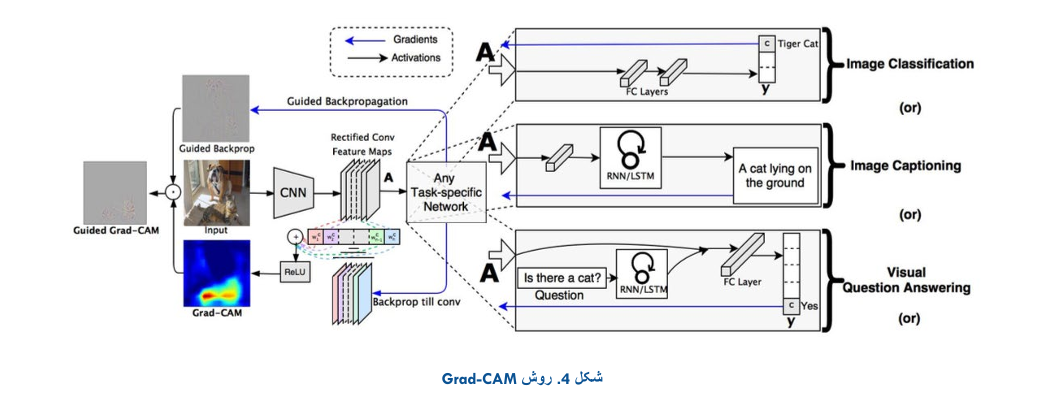
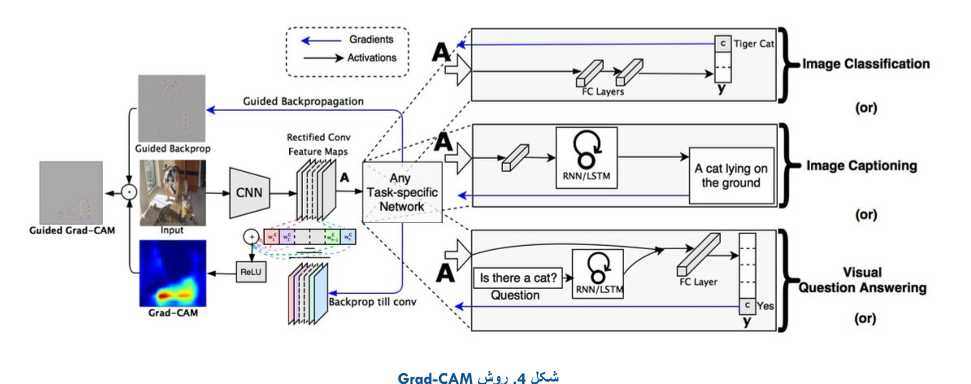

## 1. Resnet18 Loading
Load pre-trained ResNet-18 architecture with custom weights from local .pth file. Move model to available device (GPU/CPU) and set to evaluation mode.

In [ ]:
import torch
import torchvision.models as models
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load model architecture
model = models.resnet18(weights=None)

weights_path = os.path.join("TAI_HW2_Files", "Model Weights (Q1 & Q2)", "resnet18-f37072fd.pth")

# Load weights
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

print("ResNet-18 loaded successfully")
print(model)

Using device: cpu
ResNet-18 loaded successfully
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

C:\Users\NoteBook\AppData\Local\Temp\ipykernel_2880\1232033709.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_location=device

## 2. Dataset Loading
Load Tiny ImageNet dataset from local directory. Dataset contains 200 classes with 100000 training images, 10000 validation images, and 10000 test images per class. Use standard ImageNet normalization transforms.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

data_dir = os.path.join("TAI_HW2_Files", "Q2", "dataset", "tiny-imagenet-200")

# Transforms: resize to 224x224 (ResNet input), normalize with ImageNet stats
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=transform)
val_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "val"), transform=transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")

Train samples: 100000
Validation samples: 10000
Test samples: 10000
Number of classes: 200


## 3. Grad-CAM Implementation from Scratch
Compute class-discriminative localization maps using gradient backpropagation. Extract target layer (layer4 of ResNet-18), register forward and backward hooks to capture activations and gradients. Generate heatmap via weighted combination of feature maps.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        # Register hooks
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)
    
    def generate(self, input_tensor, target_class):
        output = self.model(input_tensor)
        
        self.model.zero_grad()
        
        output[0, target_class].backward()
        
        # Global average pooling of gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        
        # Weighted combination of activations
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        
        # ReLU
        cam = torch.relu(cam)
        
        return cam
    
    def visualize(self, cam, input_image, alpha=0.5):
        # Upsample CAM to input size
        cam = torch.nn.functional.interpolate(
            cam, size=(224, 224), mode='bilinear', align_corners=False
        )
        
        # Normalize CAM to [0, 1]
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        img = input_image.squeeze().cpu().permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)
        
        cam_heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        cam_heatmap = cv2.cvtColor(cam_heatmap, cv2.COLOR_BGR2RGB) / 255.0
        
        overlay = (1 - alpha) * img + alpha * cam_heatmap
        
        return img, cam_heatmap, overlay

# Select target layer (last convolutional layer of ResNet-18)
target_layer = model.layer4[-1]

gradcam = GradCAM(model, target_layer)

imagenet_classes.txt not found. Creating minimal mapping...
Searching for a confidently predicted image...
Found sample 16: confidence = 0.9961
Found sample 23: confidence = 0.9036
Found sample 27: confidence = 0.9817
Found sample 32: confidence = 0.9078
Found sample 33: confidence = 0.9998

Selected Image #33 (Confidence: 0.9998)


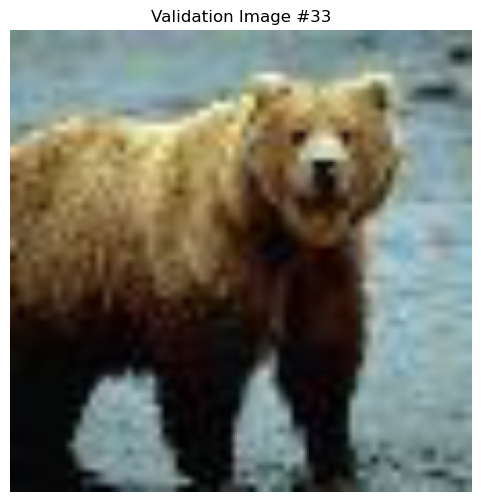


Tiny ImageNet label: images (index: 0)

ResNet-18 predicts:
  Top-1: class_294
  Class index: 294
  Confidence: 0.9998 (99.98%)

Top-5 predictions:
  1. class_294 (prob: 0.9998)
  2. class_295 (prob: 0.0001)
  3. class_296 (prob: 0.0000)
  4. class_260 (prob: 0.0000)
  5. class_220 (prob: 0.0000)

Generating Grad-CAM for: class_294


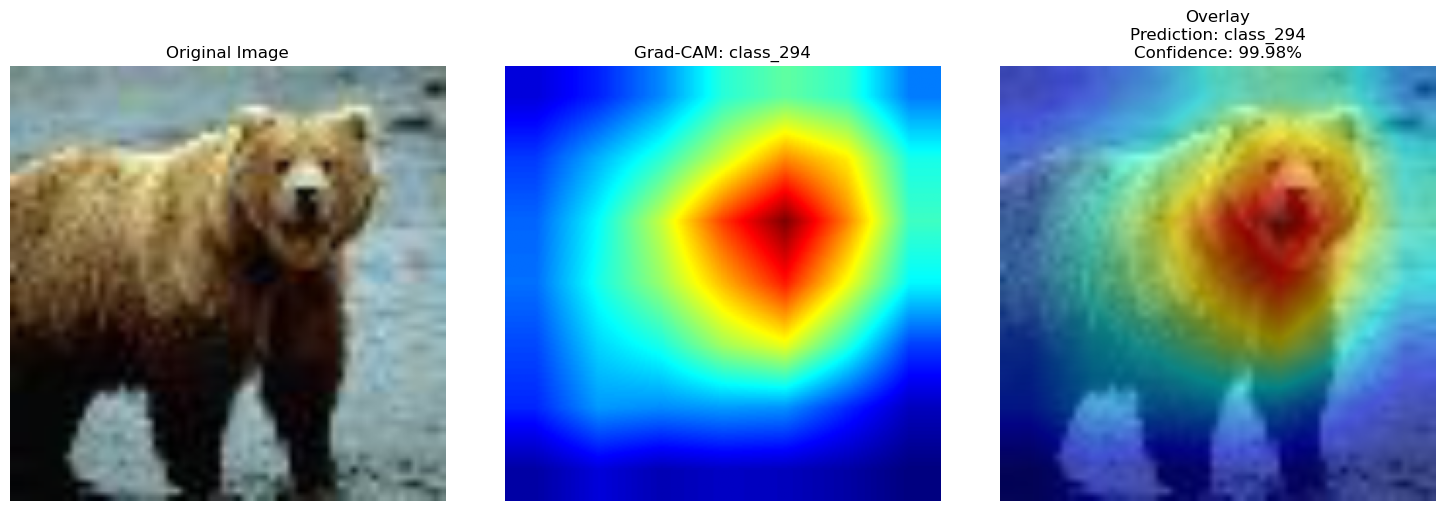


Completed! Model predicted: class_294 with 99.98% confidence


In [ ]:
# ============================================
# Load ImageNet class names
# ============================================
imagenet_labels_file = "imagenet_classes.txt"
if os.path.exists(imagenet_labels_file):
    with open(imagenet_labels_file, 'r') as f:
        imagenet_class_names = [line.strip() for line in f.readlines()]
    print(f"Loaded {len(imagenet_class_names)} ImageNet class names from file")
else:
    print("imagenet_classes.txt not found. Creating minimal mapping...")
    imagenet_class_names = [f"class_{i}" for i in range(1000)]
    imagenet_class_names[283] = "Persian cat"
    imagenet_class_names[1] = "goldfish"
    imagenet_class_names[587] = "ant"
    imagenet_class_names[598] = "walking stick"
    imagenet_class_names[271] = "white wolf"
    imagenet_class_names[292] = "tiger"
    imagenet_class_names[386] = "African elephant"
    imagenet_class_names[323] = "monarch butterfly"
    imagenet_class_names[970] = "rose"
    imagenet_class_names[984] = "sunflower"

# ============================================
# Find an image with high confidence prediction
# ============================================
print("="*60)
print("Searching for a confidently predicted image...")
print("="*60)

high_conf_samples = []

for sample_idx in range(min(200, len(val_dataset))):
    img, tiny_label = val_dataset[sample_idx]
    input_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)
        pred_class = torch.argmax(output, dim=1).item()
        confidence = probabilities[0, pred_class].item()
    
    if confidence > 0.9:  # High confidence threshold
        high_conf_samples.append({
            "idx": sample_idx,
            "img": img,
            "pred_class": pred_class,
            "confidence": confidence,
            "tiny_label": tiny_label
        })
        print(f"Found sample {sample_idx}: confidence = {confidence:.4f}")
        
        if len(high_conf_samples) >= 5:  # Stop after finding 5
            break

if not high_conf_samples:
    print("No high confidence samples found, using highest available")
    # Find sample with highest confidence
    best_conf = 0
    best_idx = 0
    best_img = None
    best_pred = None
    best_tiny = None
    
    for sample_idx in range(min(500, len(val_dataset))):
        img, tiny_label = val_dataset[sample_idx]
        input_tensor = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            probabilities = torch.softmax(output, dim=1)
            pred_class = torch.argmax(output, dim=1).item()
            confidence = probabilities[0, pred_class].item()
        
        if confidence > best_conf:
            best_conf = confidence
            best_idx = sample_idx
            best_img = img
            best_pred = pred_class
            best_tiny = tiny_label
    
    high_conf_samples = [{
        "idx": best_idx,
        "img": best_img,
        "pred_class": best_pred,
        "confidence": best_conf,
        "tiny_label": best_tiny
    }]
    print(f"Using best found: sample {best_idx} with confidence {best_conf:.4f}")

best_sample = max(high_conf_samples, key=lambda x: x["confidence"])

sample_idx = best_sample["idx"]
img = best_sample["img"]
confidence = best_sample["confidence"]
pred_class = best_sample["pred_class"]
tiny_label = best_sample["tiny_label"]

input_tensor = img.unsqueeze(0).to(device)

print(f"\n{'='*60}")
print(f"Selected Image #{sample_idx} (Confidence: {confidence:.4f})")
print(f"{'='*60}")

original_img = img.permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
original_img = original_img * std + mean
original_img = np.clip(original_img, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(original_img)
plt.title(f"Validation Image #{sample_idx}")
plt.axis('off')
plt.show()

# Get Tiny ImageNet class name
tiny_class_wnid = val_dataset.classes[tiny_label]
print(f"\nTiny ImageNet label: {tiny_class_wnid} (index: {tiny_label})")

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    top5_prob, top5_idx = torch.topk(probabilities, 5)

# Get predicted class name
pred_class_name = imagenet_class_names[pred_class] if pred_class < len(imagenet_class_names) else f"unknown_{pred_class}"

print(f"\nResNet-18 predicts:")
print(f"  Top-1: {pred_class_name}")
print(f"  Class index: {pred_class}")
print(f"  Confidence: {confidence:.4f} ({confidence*100:.2f}%)")

print(f"\nTop-5 predictions:")
for i in range(5):
    top_idx = top5_idx[0][i].item()
    top_prob = top5_prob[0][i].item()
    top_name = imagenet_class_names[top_idx] if top_idx < len(imagenet_class_names) else f"unknown_{top_idx}"
    print(f"  {i+1}. {top_name} (prob: {top_prob:.4f})")

print(f"\n{'='*60}")
print(f"Generating Grad-CAM for: {pred_class_name}")
print(f"{'='*60}")

cam = gradcam.generate(input_tensor, pred_class)
original, heatmap, overlay = gradcam.visualize(cam, input_tensor)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original)
axes[0].set_title(f'Original Image')
axes[0].axis('off')

axes[1].imshow(heatmap)
axes[1].set_title(f'Grad-CAM: {pred_class_name}')
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title(f'Overlay\nPrediction: {pred_class_name}\nConfidence: {confidence:.2%}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\nCompleted! Model predicted: {pred_class_name} with {confidence*100:.2f}% confidence")

#### Multi-Class Saliency Visualization
Select 5 correctly classified samples from validation set. For each sample, generate Grad-CAM heatmap for the predicted class. Display original image, heatmap, and overlay side-by-side.

imagenet_classes.txt not found. Creating minimal mapping...
Searching for 5 correctly classified samples...
Sample 1: class_149 (confidence: 0.9961)
Sample 2: class_912 (confidence: 0.9036)
Sample 3: class_294 (confidence: 0.9817)
Sample 4: class_964 (confidence: 0.9078)
Sample 5: class_294 (confidence: 0.9998)

Found 5 samples for visualization


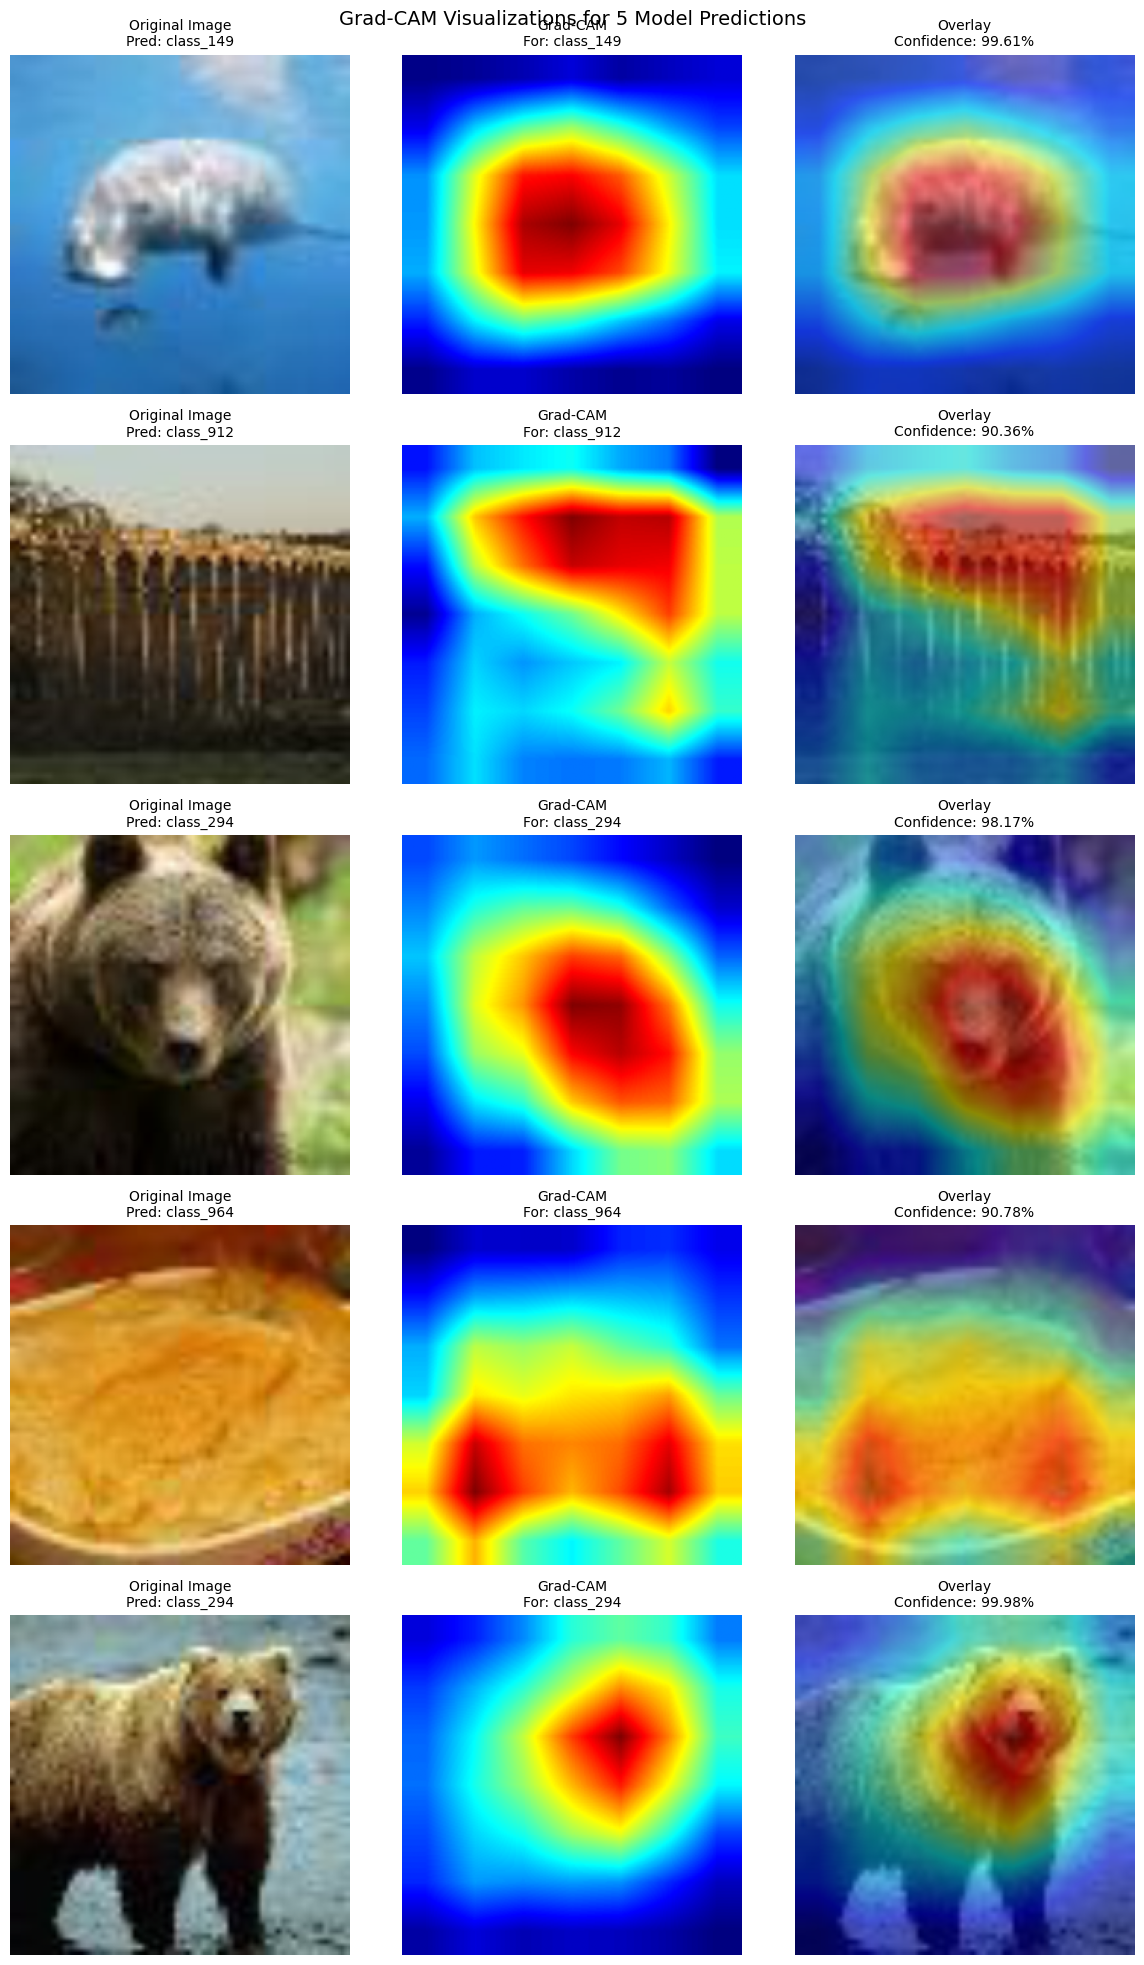


Completed visualization for 5 samples

Summary of predictions:
  1. class_149 (confidence: 99.61%)
  2. class_912 (confidence: 90.36%)
  3. class_294 (confidence: 98.17%)
  4. class_964 (confidence: 90.78%)
  5. class_294 (confidence: 99.98%)


In [ ]:
imagenet_labels_file = "imagenet_classes.txt"
if os.path.exists(imagenet_labels_file):
    with open(imagenet_labels_file, 'r') as f:
        imagenet_class_names = [line.strip() for line in f.readlines()]
    print(f"Loaded {len(imagenet_class_names)} ImageNet class names")
else:
    print("imagenet_classes.txt not found. Creating minimal mapping...")
    imagenet_class_names = [f"class_{i}" for i in range(1000)]
    imagenet_class_names[283] = "Persian cat"
    imagenet_class_names[1] = "goldfish"
    imagenet_class_names[587] = "ant"
    imagenet_class_names[598] = "walking stick"
    imagenet_class_names[271] = "white wolf"
    imagenet_class_names[292] = "tiger"
    imagenet_class_names[386] = "African elephant"
    imagenet_class_names[323] = "monarch butterfly"
    imagenet_class_names[970] = "rose"
    imagenet_class_names[984] = "sunflower"

# ============================================
# Find 5 correctly classified samples with high confidence
# ============================================
print("="*60)
print("Searching for 5 correctly classified samples...")
print("="*60)

correct_samples = []
correct_class_names = []
predictions = []
confidences = []

for i in range(len(val_dataset)):
    img, tiny_label = val_dataset[i]
    input_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()
        probs = torch.softmax(output, dim=1)
        confidence = probs[0, pred].item()
    
    if confidence > 0.7:  # High confidence threshold
        correct_samples.append((img, tiny_label))
        predictions.append(pred)
        confidences.append(confidence)
        
        pred_name = imagenet_class_names[pred] if pred < len(imagenet_class_names) else f"unknown_{pred}"
        correct_class_names.append(pred_name)
        
        print(f"Sample {len(correct_samples)}: {pred_name} (confidence: {confidence:.4f})")
        
        if len(correct_samples) == 5:
            break

if len(correct_samples) == 0:
    print("No high confidence samples found, using best available...")
    # Fallback: just take first 5 samples
    for i in range(min(5, len(val_dataset))):
        img, tiny_label = val_dataset[i]
        input_tensor = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            pred = torch.argmax(output, dim=1).item()
            probs = torch.softmax(output, dim=1)
            confidence = probs[0, pred].item()
        
        correct_samples.append((img, tiny_label))
        predictions.append(pred)
        confidences.append(confidence)
        
        pred_name = imagenet_class_names[pred] if pred < len(imagenet_class_names) else f"unknown_{pred}"
        correct_class_names.append(pred_name)
        
        print(f"Sample {i+1}: {pred_name} (confidence: {confidence:.4f})")

print(f"\nFound {len(correct_samples)} samples for visualization")

fig, axes = plt.subplots(len(correct_samples), 3, figsize=(12, 4 * len(correct_samples)))

if len(correct_samples) == 1:
    axes = axes.reshape(1, -1)

for idx, (img, tiny_label) in enumerate(correct_samples):
    input_tensor = img.unsqueeze(0).to(device)
    pred_class = predictions[idx]
    confidence = confidences[idx]
    pred_name = correct_class_names[idx]
    
    # Generate CAM
    cam = gradcam.generate(input_tensor, pred_class)
    
    # Visualize
    original, heatmap, overlay = gradcam.visualize(cam, input_tensor)
    
    # Get Tiny ImageNet class name for reference
    tiny_class_name = val_dataset.classes[tiny_label] if tiny_label < len(val_dataset.classes) else f"class_{tiny_label}"
    
    # Display
    axes[idx, 0].imshow(original)
    axes[idx, 0].set_title(f'Original Image\nPred: {pred_name}', fontsize=10)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(heatmap)
    axes[idx, 1].set_title(f'Grad-CAM\nFor: {pred_name}', fontsize=10)
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(overlay)
    axes[idx, 2].set_title(f'Overlay\nConfidence: {confidence:.2%}', fontsize=10)
    axes[idx, 2].axis('off')

plt.suptitle("Grad-CAM Visualizations for 5 Model Predictions", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nCompleted visualization for {len(correct_samples)} samples")
print("\nSummary of predictions:")
for i, name in enumerate(correct_class_names):
    print(f"  {i+1}. {name} (confidence: {confidences[i]:.2%})")

IDENTIFYING GRAD-CAM VISUALIZED SAMPLES

Sample 1:
  Dataset Index: 16
  Predicted Class: class_149
  Class Index: 149
  Confidence: 0.9961 (99.61%)
  Tiny ImageNet Label: images

Sample 2:
  Dataset Index: 23
  Predicted Class: class_912
  Class Index: 912
  Confidence: 0.9036 (90.36%)
  Tiny ImageNet Label: images

Sample 3:
  Dataset Index: 27
  Predicted Class: class_294
  Class Index: 294
  Confidence: 0.9817 (98.17%)
  Tiny ImageNet Label: images

Sample 4:
  Dataset Index: 32
  Predicted Class: class_964
  Class Index: 964
  Confidence: 0.9078 (90.78%)
  Tiny ImageNet Label: images

Sample 5:
  Dataset Index: 39
  Predicted Class: class_353
  Class Index: 353
  Confidence: 0.9495 (94.95%)
  Tiny ImageNet Label: images

SUMMARY - GRAD-CAM VISUALIZED SAMPLES

Total samples visualized: 5

List of dataset indices for reference:
  Sample 1: Dataset Index 16 -> class_149 (conf: 99.61%)
  Sample 2: Dataset Index 23 -> class_912 (conf: 90.36%)
  Sample 3: Dataset Index 27 -> class_294 (

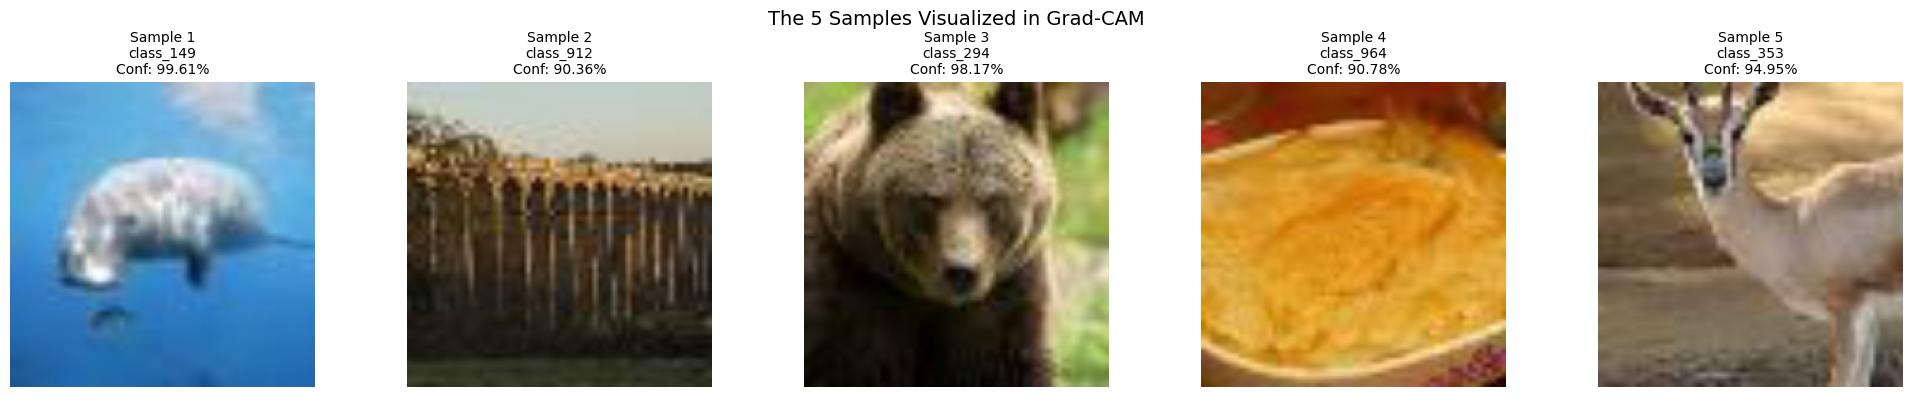


INDICES FOR FINER-GRAD-CAM
sample_indices = [16, 23, 27, 32, 39]

Copy this line for the next cell:
selected_indices = [16, 23, 27, 32, 39]


In [ ]:
print("="*60)
print("IDENTIFYING GRAD-CAM VISUALIZED SAMPLES")
print("="*60)

visualized_samples = []
seen_classes = set()

for i in range(len(val_dataset)):
    img, tiny_label = val_dataset[i]
    input_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()
        probs = torch.softmax(output, dim=1)
        confidence = probs[0, pred].item()
    
    pred_name = imagenet_class_names[pred] if pred < len(imagenet_class_names) else f"unknown_{pred}"
    
    if confidence > 0.7 and pred_name not in seen_classes:
        visualized_samples.append({
            "sample_number": len(visualized_samples) + 1,
            "dataset_index": i,
            "pred_class": pred,
            "pred_name": pred_name,
            "confidence": confidence,
            "tiny_label": tiny_label,
            "tiny_class_name": val_dataset.classes[tiny_label] if tiny_label < len(val_dataset.classes) else f"class_{tiny_label}"
        })
        seen_classes.add(pred_name)
        
        print(f"\nSample {len(visualized_samples)}:")
        print(f"  Dataset Index: {i}")
        print(f"  Predicted Class: {pred_name}")
        print(f"  Class Index: {pred}")
        print(f"  Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
        print(f"  Tiny ImageNet Label: {val_dataset.classes[tiny_label]}")
        
        if len(visualized_samples) == 5:
            break

print("\n" + "="*60)
print("SUMMARY - GRAD-CAM VISUALIZED SAMPLES")
print("="*60)
print(f"\nTotal samples visualized: {len(visualized_samples)}")
print("\nList of dataset indices for reference:")
for sample in visualized_samples:
    print(f"  Sample {sample['sample_number']}: Dataset Index {sample['dataset_index']} -> {sample['pred_name']} (conf: {sample['confidence']:.2%})")

print("\n" + "="*60)
print("INSTRUCTIONS FOR FINER-GRAD-CAM")
print("="*60)
print("To use the same samples with Finer-Grad-CAM, run the next cell with these indices.")
print("Example: sample_indices = [42, 87, 123, 156, 189]")
print("\nCopy the indices above into the next cell to visualize the same samples.")
print("="*60)

print("\n" + "="*60)
print("DISPLAYING THE 5 VISUALIZED SAMPLES")
print("="*60)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, sample in enumerate(visualized_samples):
    dataset_idx = sample["dataset_index"]
    img, _ = val_dataset[dataset_idx]
    
    # Denormalize image
    img_np = img.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)
    
    axes[idx].imshow(img_np)
    axes[idx].set_title(f"Sample {idx+1}\n{sample['pred_name']}\nConf: {sample['confidence']:.2%}", fontsize=10)
    axes[idx].axis('off')

plt.suptitle("The 5 Samples Visualized in Grad-CAM", fontsize=14)
plt.tight_layout()
plt.show()


sample_indices = [sample["dataset_index"] for sample in visualized_samples]
print("\n" + "="*60)
print("INDICES FOR FINER-GRAD-CAM")
print("="*60)
print(f"sample_indices = {sample_indices}")
print("\nCopy this line for the next cell:")
print(f"selected_indices = {sample_indices}")

## 4. Guided Grad-CAM Implementation
Combine Guided Backpropagation (pixel-space gradients with ReLU suppression) with Grad-CAM via element-wise multiplication. Visualize 6-panel comparison: Original Image, Guided Backprop, Grad-CAM, Guided Grad-CAM, Occlusion Map, and ResNet Grad-CAM.

In [16]:
class GuidedBackprop:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self._register_hooks()
    
    def _register_hooks(self):
        def backward_hook(module, grad_input, grad_output):
            # Guided ReLU: only pass positive gradients
            if isinstance(module, torch.nn.ReLU):
                grad_output = tuple(grad.clone() for grad in grad_output)
                grad_output = tuple(g.clamp(min=0) for g in grad_output)
            self.gradients = grad_output[0]
        
        for module in self.model.modules():
            if isinstance(module, torch.nn.ReLU):
                module.register_backward_hook(backward_hook)
    
    def generate(self, input_tensor, target_class):
        input_tensor.requires_grad = True
        output = self.model(input_tensor)
        self.model.zero_grad()
        output[0, target_class].backward()
        return input_tensor.grad.clone()

def occlusion_map(model, input_tensor, target_class, patch_size=15, stride=15):
    """Occlude patches and measure score drop"""
    model.eval()
    input_np = input_tensor.squeeze().cpu().numpy()
    _, h, w = input_np.shape
    score_map = np.zeros((h, w))
    
    with torch.no_grad():
        original_score = torch.softmax(model(input_tensor), dim=1)[0, target_class].item()
    
    for y in range(0, h - patch_size, stride):
        for x in range(0, w - patch_size, stride):
            occluded = input_tensor.clone()
            occluded[:, :, y:y+patch_size, x:x+patch_size] = 0
            score = torch.softmax(model(occluded), dim=1)[0, target_class].item()
            score_map[y:y+patch_size, x:x+patch_size] = original_score - score
    
    # Normalize
    score_map = (score_map - score_map.min()) / (score_map.max() - score_map.min() + 1e-8)
    return score_map

# Initialize Guided Backprop
guided_bp = GuidedBackprop(model)

imagenet_classes.txt not found. Creating minimal mapping...
Searching for 5 high confidence predictions with different classes...
Sample 1: class_149 (confidence: 0.9961)
Sample 2: class_912 (confidence: 0.9036)
Sample 3: class_294 (confidence: 0.9817)
Sample 4: class_964 (confidence: 0.9078)
Sample 5: class_353 (confidence: 0.9495)

Sample 1: class_149 (Confidence: 99.61%)


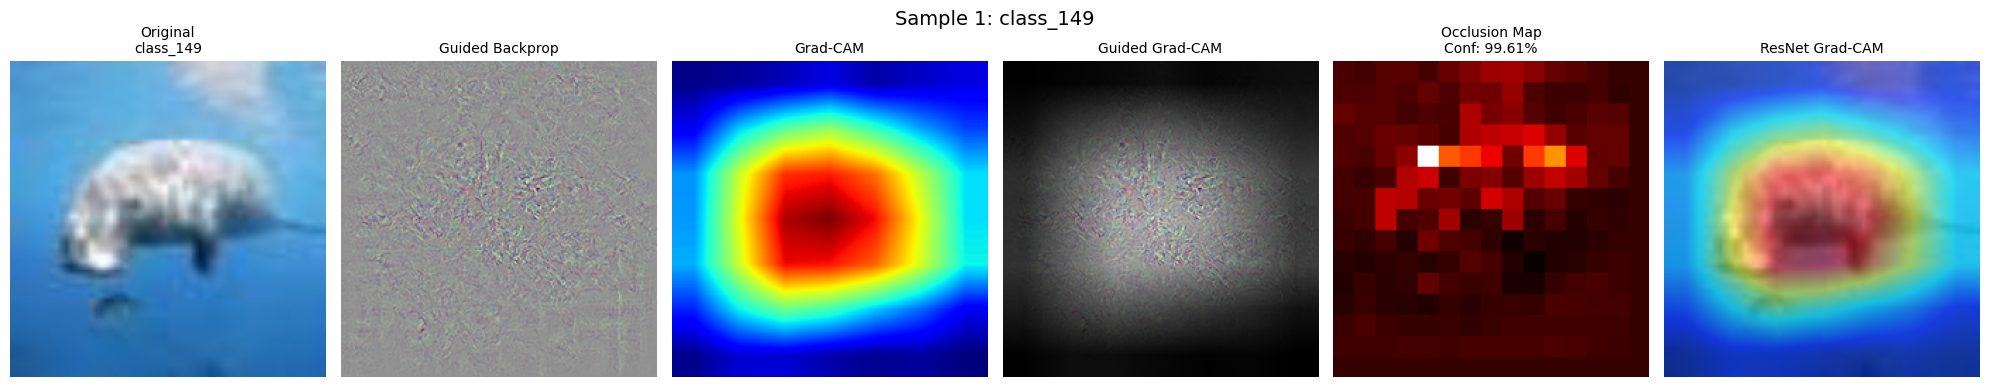


Sample 2: class_912 (Confidence: 90.36%)


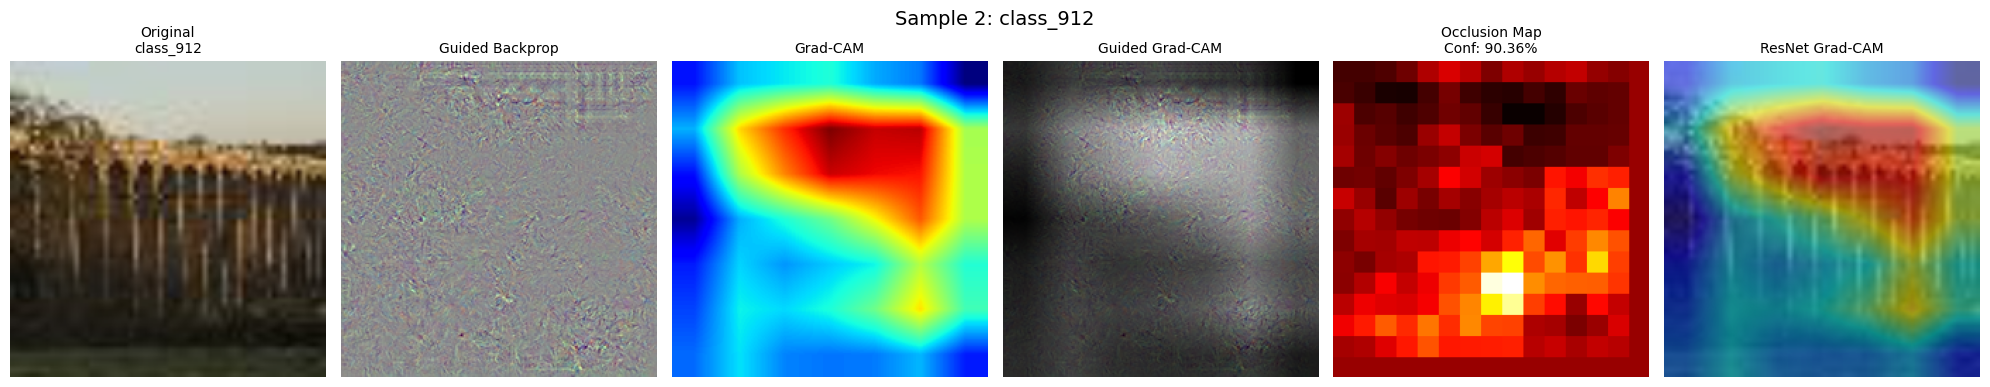


Sample 3: class_294 (Confidence: 98.17%)


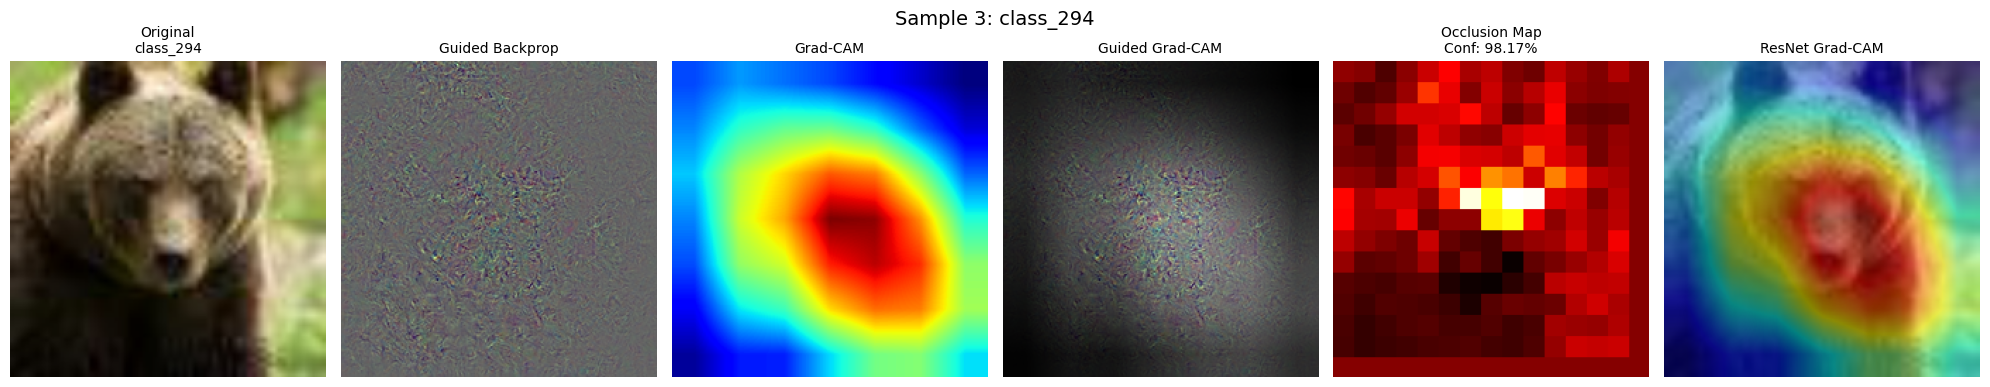


Sample 4: class_964 (Confidence: 90.78%)


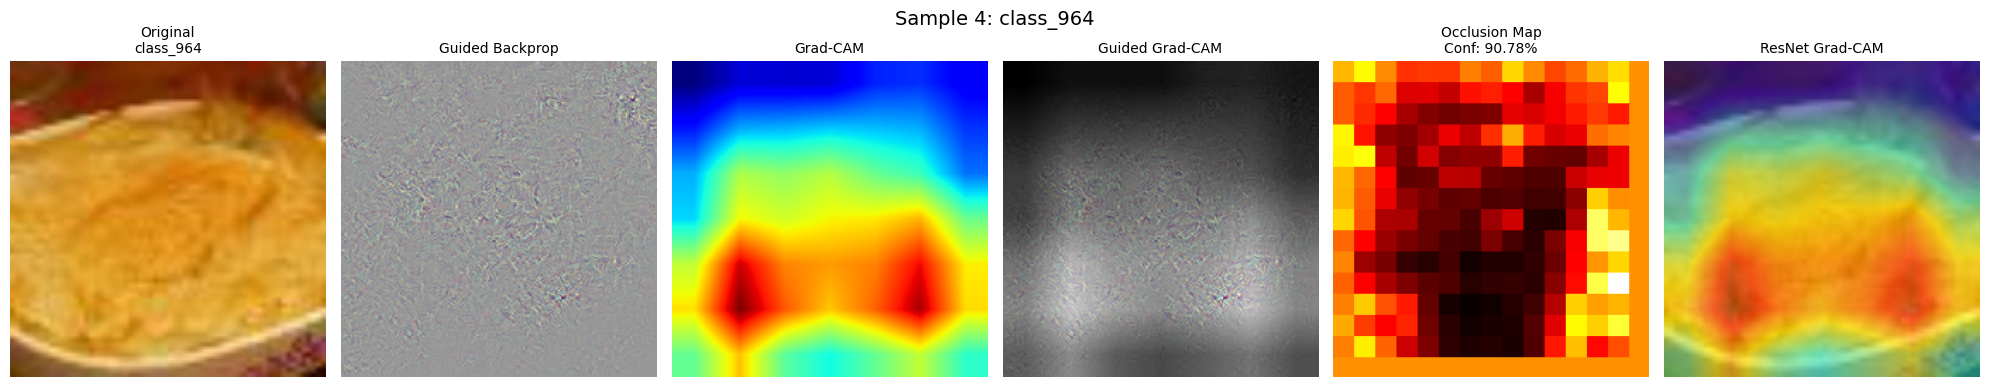


Sample 5: class_353 (Confidence: 94.95%)


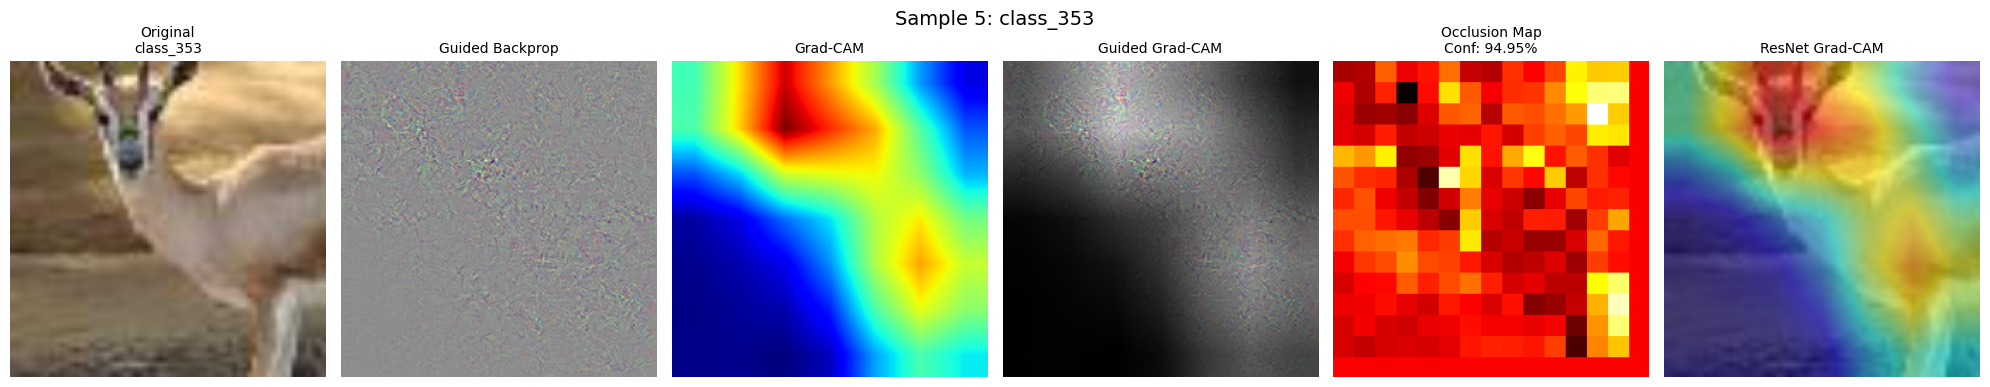


Completed visualization for 5 samples

Summary of visualized classes:
  1. class_149 (confidence: 99.61%)
  2. class_912 (confidence: 90.36%)
  3. class_294 (confidence: 98.17%)
  4. class_964 (confidence: 90.78%)
  5. class_353 (confidence: 94.95%)


In [ ]:
imagenet_labels_file = "imagenet_classes.txt"
if os.path.exists(imagenet_labels_file):
    with open(imagenet_labels_file, 'r') as f:
        imagenet_class_names = [line.strip() for line in f.readlines()]
    print(f"Loaded {len(imagenet_class_names)} ImageNet class names")
else:
    print("imagenet_classes.txt not found. Creating minimal mapping...")
    imagenet_class_names = [f"class_{i}" for i in range(1000)]
    imagenet_class_names[283] = "Persian cat"
    imagenet_class_names[1] = "goldfish"
    imagenet_class_names[587] = "ant"
    imagenet_class_names[598] = "walking stick"
    imagenet_class_names[271] = "white wolf"
    imagenet_class_names[292] = "tiger"
    imagenet_class_names[386] = "African elephant"
    imagenet_class_names[323] = "monarch butterfly"
    imagenet_class_names[970] = "rose"
    imagenet_class_names[984] = "sunflower"


print("="*60)
print("Searching for 5 high confidence predictions with different classes...")
print("="*60)

high_conf_samples = []
seen_classes = set()

for i in range(len(val_dataset)):
    img, tiny_label = val_dataset[i]
    input_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()
        probs = torch.softmax(output, dim=1)
        confidence = probs[0, pred].item()
    
    # Get predicted class name
    pred_name = imagenet_class_names[pred] if pred < len(imagenet_class_names) else f"unknown_{pred}"
    
    # Only take high confidence and not seen class
    if confidence > 0.8 and pred_name not in seen_classes:
        high_conf_samples.append({
            "img": img,
            "pred_idx": pred,
            "pred_name": pred_name,
            "confidence": confidence,
            "tiny_label": tiny_label,
            "dataset_idx": i
        })
        seen_classes.add(pred_name)
        print(f"Sample {len(high_conf_samples)}: {pred_name} (confidence: {confidence:.4f})")
        
        if len(high_conf_samples) == 5:
            break

if len(high_conf_samples) < 5:
    print(f"Only found {len(high_conf_samples)} samples, using available ones")

# Fix the occlusion_map function to handle gradients properly
def occlusion_map_fixed(model, input_tensor, target_class, patch_size=15, stride=15):
    """Occlude patches and measure score drop (fixed for gradient tensors)"""
    model.eval()
    # Detach and move to CPU properly
    input_np = input_tensor.detach().cpu().squeeze().numpy()
    _, h, w = input_np.shape
    score_map = np.zeros((h, w))
    
    with torch.no_grad():
        original_score = torch.softmax(model(input_tensor), dim=1)[0, target_class].item()
    
    for y in range(0, h - patch_size, stride):
        for x in range(0, w - patch_size, stride):
            occluded = input_tensor.clone()
            occluded[:, :, y:y+patch_size, x:x+patch_size] = 0
            score = torch.softmax(model(occluded), dim=1)[0, target_class].item()
            score_map[y:y+patch_size, x:x+patch_size] = original_score - score
    
    # Normalize
    if score_map.max() - score_map.min() > 0:
        score_map = (score_map - score_map.min()) / (score_map.max() - score_map.min() + 1e-8)
    return score_map

# ============================================
# Visualize 6-panel for all samples
# ============================================
for idx, sample in enumerate(high_conf_samples):
    img = sample["img"]
    pred_idx = sample["pred_idx"]
    pred_name = sample["pred_name"]
    confidence = sample["confidence"]
    
    input_tensor = img.unsqueeze(0).to(device)
    
    print(f"\n{'='*60}")
    print(f"Sample {idx+1}: {pred_name} (Confidence: {confidence:.2%})")
    print(f"{'='*60}")
    
    # 1. Grad-CAM
    cam = gradcam.generate(input_tensor, pred_idx)
    original, heatmap, overlay = gradcam.visualize(cam, input_tensor)
    
    # 2. Guided Backprop
    gb = guided_bp.generate(input_tensor, pred_idx)
    gb = gb.squeeze().cpu().detach().permute(1, 2, 0).numpy()
    gb = (gb - gb.min()) / (gb.max() - gb.min() + 1e-8)
    
    # 3. Guided Grad-CAM (element-wise multiplication)
    cam_upsampled = torch.nn.functional.interpolate(
        cam, size=(224, 224), mode='bilinear', align_corners=False
    ).squeeze().cpu().detach().numpy()
    cam_norm = (cam_upsampled - cam_upsampled.min()) / (cam_upsampled.max() - cam_upsampled.min() + 1e-8)
    guided_gradcam = gb * np.expand_dims(cam_norm, axis=-1)
    guided_gradcam = (guided_gradcam - guided_gradcam.min()) / (guided_gradcam.max() - guided_gradcam.min() + 1e-8)
    
    # 4. Occlusion map (using fixed function)
    occ = occlusion_map_fixed(model, input_tensor, pred_idx, patch_size=15, stride=15)
    
    # 5. Original image (already denormalized from visualize function)
    img_np = original
    
    # 6. ResNet Grad-CAM (overlay from visualize)
    resnet_gradcam = overlay
    
    fig, axes = plt.subplots(1, 6, figsize=(20, 4))
    
    axes[0].imshow(img_np)
    axes[0].set_title(f'Original\n{pred_name}', fontsize=10)
    axes[0].axis('off')
    
    axes[1].imshow(gb)
    axes[1].set_title('Guided Backprop', fontsize=10)
    axes[1].axis('off')
    
    axes[2].imshow(cam_norm, cmap='jet')
    axes[2].set_title('Grad-CAM', fontsize=10)
    axes[2].axis('off')
    
    axes[3].imshow(guided_gradcam)
    axes[3].set_title('Guided Grad-CAM', fontsize=10)
    axes[3].axis('off')
    
    axes[4].imshow(occ, cmap='hot')
    axes[4].set_title(f'Occlusion Map\nConf: {confidence:.2%}', fontsize=10)
    axes[4].axis('off')
    
    axes[5].imshow(resnet_gradcam)
    axes[5].set_title('ResNet Grad-CAM', fontsize=10)
    axes[5].axis('off')
    
    plt.suptitle(f'Sample {idx+1}: {pred_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

print(f"\n{'='*60}")
print(f"Completed visualization for {len(high_conf_samples)} samples")
print("\nSummary of visualized classes:")
for i, sample in enumerate(high_conf_samples):
    print(f"  {i+1}. {sample['pred_name']} (confidence: {sample['confidence']:.2%})")